# Credit Risk Feature Engineering, Preprocessing, Machine Learning, and Bayesian Modeling

| | |
|---|---|
| **Notebook** | B_Feature_Engineering_Preprocessing_and_ML.ipynb |
| **Author** | N L N Sai Krishna Akula |
| **Course** | AAI 500 - Applied Statistics & AI |
| **Dataset** | Credit Risk Modeling Dataset |
| **Date** | June 3, 2026 |
| **GitHub** | https://github.com/diaeshantony-usd/applied-statistics-and-ai-team-project |

This notebook presents a complete modeling workflow from the cleaned credit risk dataset. The workflow includes feature engineering, preprocessing, Scikit-learn machine learning models, Bayesian Network modeling, regression-based loan sizing, and final model comparison tables.

---
## 1. Project Setup and Data Audit

### 1.1 Modeling Objectives

The project has two modeling goals. The first goal is to predict loan default using `loan_status`, where `0` represents non-default and `1` represents default. This is a classification task.

The second goal is to estimate a reasonable loan amount and loan-to-income percentage. This is a regression task because `loan_amnt` and `loan_percent_income` are numeric targets.

The regression output is a decision-support benchmark based on historical data. It should not be interpreted as a guaranteed loan approval amount.

---
### 1.2 Setup and Environment

This section imports the required libraries and sets the main configuration values. A fixed random seed is used so train-test splits and model results are reproducible.

In [245]:
# Run this cell only if inferential-statistics and Bayesian Network packages are not already installed
!pip install scipy
!pip install pgmpy networkx

In [246]:
# Core data libraries
import warnings

import numpy as np
import pandas as pd

# Visualization libraries
import matplotlib.pyplot as plt
import networkx as nx
import seaborn as sns

# Inferential statistics
from scipy import stats

# Scikit-learn preprocessing
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

# Scikit-learn model selection and metrics
from sklearn.model_selection import StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)

# Scikit-learn estimators
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TEST_SIZE = 0.20
DATA_PATH = "../data/processed/credit_risk_cleaned.csv"

print("Libraries loaded successfully.")
print("Dataset configured:", DATA_PATH)

Libraries loaded successfully.
Dataset configured: ../data/processed/credit_risk_cleaned.csv


---
### 1.3 Load and Audit the Cleaned Dataset

The modeling workflow starts from `credit_risk_cleaned.csv`, which is the processed dataset from the data preparation stage. The audit is separated into small outputs so each check is easy to explain in a final project presentation.

The first check confirms that the cleaned file loads correctly and shows the dataset size.

In [247]:
df = pd.read_csv(DATA_PATH)

# Print a short load confirmation without exposing any local full file path.
print("Dataset loaded successfully.")
print("Shape:", df.shape)

Dataset loaded successfully.
Shape: (29567, 12)


The first five rows provide a quick visual check of the columns and sample values.

In [248]:
# Display sample records to verify the dataset structure before modeling.
display(df.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2


The preview confirms that borrower details, loan details, and credit history fields are available for modeling. This check helps ensure that later feature engineering uses the expected columns.

In [249]:
# Collect categorical columns and list their levels before encoding.
categorical_cols_initial = df.select_dtypes(include=["object", "category"]).columns.tolist()
categorical_summary = {
    col: sorted(df[col].dropna().astype(str).unique().tolist())
    for col in categorical_cols_initial
}
display(pd.DataFrame({
    "column": list(categorical_summary.keys()),
    "levels": [", ".join(vals) for vals in categorical_summary.values()],
}))

,column,levels
0,person_home_ownership,"MORTGAGE, OTHER, OWN, RENT"
1,loan_intent,"DEBTCONSOLIDATION, EDUCATION, HOMEIMPROVEMENT,..."
2,loan_grade,"A, B, C, D, E, F, G"
3,cb_person_default_on_file,"N, Y"


Numeric summary statistics show the scale and range of each numeric field before feature engineering.

In [250]:
# Review numeric ranges and distributions before feature engineering.
display(df.describe().T.round(3))

,count,mean,std,min,25%,50%,75%,max
person_age,29567.0,26.726,4.507,20.00,23.00,25.00,29.00,40.00
person_income,29567.0,58588.391,27477.043,4080.00,37863.00,54000.00,75000.00,140004.00
person_emp_length,29567.0,4.629,3.769,0.00,2.00,4.00,7.00,25.00
loan_amnt,29567.0,9278.747,6024.906,500.00,5000.00,8000.00,12000.00,35000.00
loan_int_rate,29567.0,11.000,3.078,5.42,8.49,10.99,13.11,23.22
loan_status,29567.0,0.224,0.417,0.00,0.00,0.00,0.00,1.00
loan_percent_income,29567.0,0.175,0.107,0.01,0.09,0.15,0.23,0.83
cb_person_cred_hist_length,29567.0,5.269,3.315,2.00,3.00,4.00,7.00,17.00


---
## 2. Feature Engineering and Exploratory Analysis

### 2.1 Feature Engineering

This step creates extra columns that make the credit problem easier to understand. The new columns describe income level, loan burden, age group, and past default behavior.

Log transformations reduce the influence of very large financial values. Ratio features compare borrower capacity with requested loan size. Grouped features such as `income_group`, `loan_amount_group`, `loan_percent_income_group`, and `age_group` make default patterns easier to explain.

In [251]:
def add_credit_features(data):
    # Copy the input so the original cleaned dataset is not modified directly.
    out = data.copy()

    # Log transforms reduce the influence of very large income and loan values.
    out["log_person_income"] = np.log1p(out["person_income"])
    out["log_loan_amnt"] = np.log1p(out["loan_amnt"])

    # Ratio features describe affordability and borrower history in relative terms.
    out["income_to_loan_ratio"] = out["person_income"] / out["loan_amnt"].clip(lower=1)
    out["employment_to_age_ratio"] = out["person_emp_length"] / out["person_age"].clip(lower=1)
    out["credit_history_to_age_ratio"] = out["cb_person_cred_hist_length"] / out["person_age"].clip(lower=1)
    out["default_on_file_binary"] = (out["cb_person_default_on_file"] == "Y").astype(int)

    # Numeric grade is useful for analysis while model preprocessing still handles grade encoding.
    grade_map = {"A": 0, "B": 1, "C": 2, "D": 3, "E": 4, "F": 5, "G": 6}
    out["loan_grade_numeric"] = out["loan_grade"].map(grade_map)

    # Grouped features make borrower and loan risk patterns easier to explain.
    out["income_group"] = pd.cut(
        out["person_income"],
        bins=[0, 25000, 50000, 75000, 100000, np.inf],
        labels=["Low", "Lower-Middle", "Middle", "Upper-Middle", "High"],
        include_lowest=True,
    )
    out["loan_amount_group"] = pd.cut(
        out["loan_amnt"],
        bins=[0, 5000, 10000, 20000, np.inf],
        labels=["Small", "Medium", "Large", "Very Large"],
        include_lowest=True,
    )
    out["loan_percent_income_group"] = pd.cut(
        out["loan_percent_income"],
        bins=[0, 0.10, 0.20, 0.35, np.inf],
        labels=["Low Burden", "Moderate Burden", "High Burden", "Very High Burden"],
        include_lowest=True,
    )
    out["age_group"] = pd.cut(
        out["person_age"],
        bins=[0, 25, 35, np.inf],
        labels=["Young", "Adult", "Experienced Adult"],
        include_lowest=True,
    )
    # Return the feature-engineered dataframe for all later modeling steps.
    return out

In [252]:
df_model = add_credit_features(df)

# Print the new shape after engineered columns are added.
print("Feature-engineered dataset shape:", df_model.shape)

Feature-engineered dataset shape: (29567, 23)


In [253]:
# Preview engineered columns to confirm the feature creation step.
display(df_model.head())

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,log_person_income,log_loan_amnt,income_to_loan_ratio,employment_to_age_ratio,credit_history_to_age_ratio,default_on_file_binary,loan_grade_numeric,income_group,loan_amount_group,loan_percent_income_group,age_group
0,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2,9.169623,6.908755,9.600000,0.238095,0.095238,0,1,Low,Small,Low Burden,Young
1,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3,9.169623,8.612685,1.745455,0.040000,0.120000,0,2,Low,Medium,Very High Burden,Young
2,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2,11.089821,10.463132,1.871429,0.173913,0.086957,0,2,Middle,Very Large,Very High Burden,Young
3,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4,10.904138,10.463132,1.554286,0.333333,0.166667,1,2,Middle,Very Large,Very High Burden,Young
4,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2,9.200391,7.824446,3.960000,0.095238,0.095238,0,0,Low,Small,High Burden,Young


---
### 2.2 Grouped Feature Default Rate EDA

Grouped features help explain whether risk changes across borrower and loan categories. The outputs below show default rate separately for income group, loan amount group, and loan burden group.

In [254]:
def summarize_default_rate_by_group(data, group_col):
    # Group by the selected category and calculate default rate plus loan-size context.
    summary = (
        data.groupby(group_col, observed=False)
        .agg(
            loan_count=("loan_status", "size"),
            default_rate=("loan_status", "mean"),
            avg_loan_amount=("loan_amnt", "mean"),
            avg_loan_percent_income=("loan_percent_income", "mean"),
        )
        .reset_index()
    )
    # Return a compact table that can be displayed or plotted.
    return summary

The income group table shows whether lower or higher income bands have different default rates.

In [255]:
income_group_summary = summarize_default_rate_by_group(df_model, "income_group")

# Display default rate by income band.
display(income_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
}))

,income_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Low,2356,52.42%,4674.73,23.95%
1,Lower-Middle,11086,27.76%,7665.95,20.14%
2,Middle,9142,17.57%,10005.58,16.06%
3,Upper-Middle,4410,10.93%,11891.41,13.66%
4,High,2573,9.17%,13382.89,11.42%


This table compares default behavior across income groups. Higher default rates in a group suggest that income level is related to credit risk and should remain part of the modeling dataset.

The loan amount group table checks whether larger requested loans behave differently from smaller loans.

In [256]:
loan_amount_group_summary = summarize_default_rate_by_group(df_model, "loan_amount_group")

# Display default rate by loan amount band.
display(loan_amount_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
}))

,loan_amount_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Small,8890,20.79%,3472.02,9.28%
1,Medium,11095,18.46%,7849.32,16.80%
2,Large,7978,26.45%,14542.89,24.58%
3,Very Large,1604,39.28%,25166.57,31.79%


This table compares default behavior across loan amount groups. It helps show whether larger requested loans are associated with different repayment outcomes.

The loan percent income group table focuses on loan burden, which is usually more informative than loan amount alone.

In [257]:
loan_percent_income_group_summary = summarize_default_rate_by_group(df_model, "loan_percent_income_group")

# Display default rate by loan burden band.
display(loan_percent_income_group_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_loan_amount": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
}))

,loan_percent_income_group,loan_count,default_rate,avg_loan_amount,avg_loan_percent_income
0,Low Burden,8980,12.19%,4538.56,6.76%
1,Moderate Burden,11051,15.08%,9098.00,15.23%
2,High Burden,7461,32.02%,13206.21,26.58%
3,Very High Burden,2075,71.61%,16633.75,42.78%


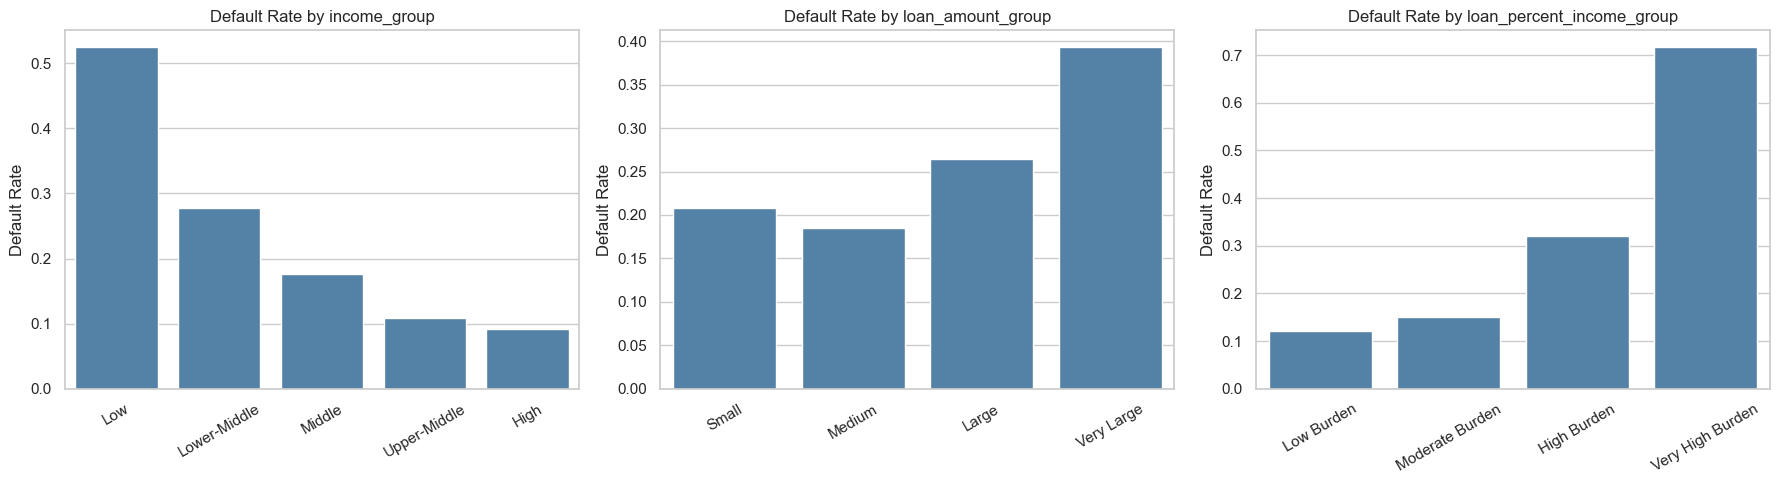

In [258]:
# Store grouped summaries so the plots can be generated consistently.
group_feature_summaries = {
    "income_group": income_group_summary,
    "loan_amount_group": loan_amount_group_summary,
    "loan_percent_income_group": loan_percent_income_group_summary,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, group_name in zip(axes, group_feature_summaries.keys()):
    summary = group_feature_summaries[group_name]
    sns.barplot(data=summary, x=group_name, y="default_rate", color="steelblue", ax=ax)
    ax.set_title(f"Default Rate by {group_name}")
    ax.set_xlabel("")
    ax.set_ylabel("Default Rate")
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

---
### 2.3 Credit Grade and Interest Rate Analysis

The main classification model uses an issued-loan framing, so `loan_grade` and `loan_int_rate` are included because those values are known after underwriting. This section checks how default rate and interest rate change across grades.

In [259]:
# Summarize default behavior and interest rate patterns by loan grade.
grade_summary = (
    df_model.groupby("loan_grade")
    .agg(
        loan_count=("loan_status", "size"),
        default_rate=("loan_status", "mean"),
        avg_interest_rate=("loan_int_rate", "mean"),
        avg_loan_percent_income=("loan_percent_income", "mean"),
    )
    .reset_index()
)
display(grade_summary.style.format({
    "default_rate": "{:.2%}",
    "avg_interest_rate": "{:.2f}",
    "avg_loan_percent_income": "{:.2%}",
}))

,loan_grade,loan_count,default_rate,avg_interest_rate,avg_loan_percent_income
0,A,9818,10.46%,7.66,15.75%
1,B,9442,16.92%,11.00,17.98%
2,C,5897,21.64%,13.23,17.46%
3,D,3285,59.91%,14.98,19.60%
4,E,857,65.23%,16.44,21.23%
5,F,209,71.77%,17.76,22.62%
6,G,59,98.31%,19.38,24.95%


The grade and interest-rate summary shows how lender-assigned grades relate to default rates and pricing. This supports including grade and rate in the issued-loan modeling view.

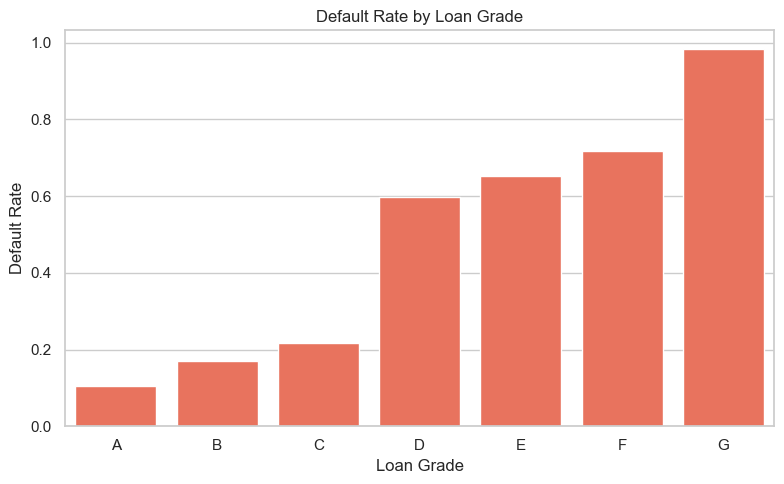

In [260]:
# Plot a focused relationship so grade-level risk is easier to read.
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=grade_summary, x="loan_grade", y="default_rate", color="tomato", ax=ax)
ax.set_title("Default Rate by Loan Grade")
ax.set_xlabel("Loan Grade")
ax.set_ylabel("Default Rate")
plt.tight_layout()
plt.show()

In [261]:
def summarize_default_probability(data, group_cols):
    # Empirical conditional probabilities
    summary = (
        data.groupby(group_cols, observed=False)
        .agg(
            loan_count=("loan_status", "size"),
            default_probability=("loan_status", "mean"),
        )
        .reset_index()
        .sort_values("default_probability", ascending=False)
    )
    return summary


bn_probability_by_burden = summarize_default_probability(
    df_model, ["loan_percent_income_group", "cb_person_default_on_file"]
)

# Display conditional default probabilities by loan burden and prior default flag.
display(bn_probability_by_burden.style.format({"default_probability": "{:.2%}"}))

,loan_percent_income_group,cb_person_default_on_file,loan_count,default_probability
7,Very High Burden,Y,403,79.16%
6,Very High Burden,N,1672,69.80%
5,High Burden,Y,1494,48.06%
3,Moderate Burden,Y,1844,31.29%
4,High Burden,N,5967,28.00%
1,Low Burden,Y,1461,26.63%
2,Moderate Burden,N,9207,11.83%
0,Low Burden,N,7519,9.39%


---
## 3. Statistical and Bayesian Analysis

### 3.1 Inferential Statistics

Inferential statistics help check whether group differences look real or could just be random. This dataset supports mean-comparison tests for borrower, loan, and credit-history variables.

Welch's t-test is used for two-group comparisons between default and non-default loans because it does not assume equal variance between the groups. One-way ANOVA is used to compare numeric means across more than two credit grades.

**H0** means the null hypothesis. It represents the assumption that there is no real difference between the groups being compared. If the p-value is below 0.05, the result rejects H0, meaning the observed difference is unlikely to be explained by random variation alone.

In [262]:
ALPHA = 0.05

ttest_numeric_features = [
    "person_income", "loan_amnt", "loan_percent_income",
    "loan_int_rate", "person_emp_length", "cb_person_cred_hist_length",
]


def run_welch_tests(data, features, target_col="loan_status", alpha=ALPHA):
    # Welch's t-test compares numeric means between default and non-default loans.
    rows = []
    for feature in features:
        non_default_values = data.loc[data[target_col] == 0, feature].dropna()
        default_values = data.loc[data[target_col] == 1, feature].dropna()

        # equal_var=False applies Welch's version of the independent t-test.
        statistic, p_value = stats.ttest_ind(
            non_default_values,
            default_values,
            equal_var=False,
            nan_policy="omit",
        )
        decision = "Reject H0" if p_value < alpha else "Fail to reject H0"
        interpretation = (
            "Reject H0: evidence suggests the mean differs by default status."
            if p_value < alpha
            else "Fail to reject H0: no statistically significant mean difference found."
        )
        rows.append({
            "test": "Welch t-test",
            "feature": feature,
            "h0": f"The mean {feature} is the same for default and non-default loans.",
            "statistic": statistic,
            "p_value": p_value,
            "decision": decision,
            "interpretation": interpretation,
        })
    return pd.DataFrame(rows)


welch_results = run_welch_tests(df_model, ttest_numeric_features)

# Display Welch test results for default vs non-default groups.
display(welch_results.style.format({"statistic": "{:.4f}", "p_value": "{:.6f}"}))

,test,feature,h0,statistic,p_value,decision,interpretation
0,Welch t-test,person_income,The mean person_income is the same for default and non-default loans.,49.0411,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
1,Welch t-test,loan_amnt,The mean loan_amnt is the same for default and non-default loans.,-18.6629,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
2,Welch t-test,loan_percent_income,The mean loan_percent_income is the same for default and non-default loans.,-56.8847,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
3,Welch t-test,loan_int_rate,The mean loan_int_rate is the same for default and non-default loans.,-54.1217,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
4,Welch t-test,person_emp_length,The mean person_emp_length is the same for default and non-default loans.,15.2853,0.000000,Reject H0,Reject H0: evidence suggests the mean differs by default status.
5,Welch t-test,cb_person_cred_hist_length,The mean cb_person_cred_hist_length is the same for default and non-default loans.,3.2448,0.001179,Reject H0,Reject H0: evidence suggests the mean differs by default status.


For Welch's t-tests, H0 means the average numeric value is the same for default and non-default loans. When the p-value is below 0.05, H0 is rejected, meaning the feature shows a statistically meaningful difference between the two credit-outcome groups.

In [263]:
anova_numeric_features = [
    "person_income", "loan_amnt", "loan_percent_income",
    "loan_int_rate", "person_emp_length", "cb_person_cred_hist_length",
]

def run_grade_anova(data, features, group_col="loan_grade", alpha=ALPHA):
    # One-way ANOVA compares numeric means across all loan-grade groups.
    rows = []
    for feature in features:
        grouped_values = [
            group[feature].dropna()
            for _, group in data.groupby(group_col)
            if group[feature].dropna().shape[0] > 1
        ]

        # ANOVA requires at least two groups with enough observations.
        if len(grouped_values) >= 2:
            statistic, p_value = stats.f_oneway(*grouped_values)
        else:
            statistic, p_value = np.nan, np.nan

        decision = "Reject H0" if pd.notna(p_value) and p_value < alpha else "Fail to reject H0"
        interpretation = (
            "Reject H0: at least one grade group has a different mean."
            if pd.notna(p_value) and p_value < alpha
            else "Fail to reject H0: no statistically significant grade-level mean difference found."
        )
        rows.append({
            "test": "One-way ANOVA",
            "feature": feature,
            "h0": f"The mean {feature} is the same across all loan grades.",
            "statistic": statistic,
            "p_value": p_value,
            "decision": decision,
            "interpretation": interpretation,
        })
    return pd.DataFrame(rows)


anova_results = run_grade_anova(df_model, anova_numeric_features)

# Display ANOVA results for numeric variables across loan grades.
display(anova_results.style.format({"statistic": "{:.4f}", "p_value": "{:.6f}"}))

,test,feature,h0,statistic,p_value,decision,interpretation
0,One-way ANOVA,person_income,The mean person_income is the same across all loan grades.,18.6903,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
1,One-way ANOVA,loan_amnt,The mean loan_amnt is the same across all loan grades.,145.0110,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
2,One-way ANOVA,loan_percent_income,The mean loan_percent_income is the same across all loan grades.,99.7540,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
3,One-way ANOVA,loan_int_rate,The mean loan_int_rate is the same across all loan grades.,22441.2199,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
4,One-way ANOVA,person_emp_length,The mean person_emp_length is the same across all loan grades.,22.2724,0.000000,Reject H0,Reject H0: at least one grade group has a different mean.
5,One-way ANOVA,cb_person_cred_hist_length,The mean cb_person_cred_hist_length is the same across all loan grades.,1.7270,0.110263,Fail to reject H0,Fail to reject H0: no statistically significant grade-level mean difference found.


For ANOVA, H0 means the average numeric value is the same across all loan-grade groups. A rejected H0 means at least one grade group has a different average, which supports using grade-related patterns for model selection and interpretation.

---
### 3.2 Bayesian Network Model

A Bayesian Network shows how grouped variables are connected using probabilities. For this dataset, the network can be learned from grouped borrower and loan variables such as income group, loan burden group, prior default flag, loan intent, and loan grade.

This section is used for probabilistic structure interpretation. Because the data is observational, the learned DAG should not be treated as proof of real-world causality.

The fitted Bayesian Network can also estimate default probability for test records. It is used as a supporting model, while the Scikit-learn models remain the main prediction models because they use more detailed numeric information.

In [264]:
# Run this focused analysis step and display the result for project review.
from pgmpy.inference import VariableElimination
from pgmpy.estimators import HillClimbSearch, BIC
from pgmpy.models import DiscreteBayesianNetwork as PgmpyBayesianNetwork
print("pgmpy imported successfully. Bayesian Network structure learning is available.")

pgmpy imported successfully. Bayesian Network structure learning is available.


In [265]:
bn_cols = [
    "income_group", "loan_amount_group", "loan_percent_income_group",
    "age_group", "person_home_ownership", "loan_intent",
    "cb_person_default_on_file", "loan_grade", "loan_status",
]

# Use only discrete/grouped variables because Bayesian Networks in this section are categorical.
bn_data = df_model[bn_cols].copy()
bn_data["loan_status"] = bn_data["loan_status"].map({0: "Non-Default", 1: "Default"})
bn_data = bn_data.astype(str)

# Split the discrete Bayesian Network data for training and prediction evaluation.
bn_train_data, bn_test_data = train_test_split(
    bn_data,
    test_size=TEST_SIZE,
    stratify=bn_data["loan_status"],
    random_state=RANDOM_STATE,
)

# Use a training sample for structure learning so the section remains practical to run.
#bn_learning_data = bn_train_data.sample(n=min(5000, len(bn_train_data)), random_state=RANDOM_STATE)
bn_learning_data = bn_train_data
print("Bayesian Network training rows:", bn_train_data.shape[0])
print("Bayesian Network test rows:", bn_test_data.shape[0])
print("Bayesian Network structure-learning rows:", bn_learning_data.shape[0])
display(bn_learning_data.head())

Bayesian Network training rows: 23653
Bayesian Network test rows: 5914
Bayesian Network structure-learning rows: 23653


,income_group,loan_amount_group,loan_percent_income_group,age_group,person_home_ownership,loan_intent,cb_person_default_on_file,loan_grade,loan_status
19556,Low,Small,High Burden,Adult,RENT,VENTURE,Y,C,Default
17624,High,Large,Moderate Burden,Adult,RENT,MEDICAL,Y,F,Default
14146,High,Large,Moderate Burden,Young,MORTGAGE,VENTURE,N,B,Non-Default
17846,Lower-Middle,Large,Very High Burden,Adult,RENT,PERSONAL,Y,C,Default
2255,Low,Small,High Burden,Young,RENT,PERSONAL,Y,D,Default


In [266]:
bn_model = None
bn_edges = []
bn_metrics = None


# HillClimbSearch learns a DAG structure using a discrete scoring method.
hill_search = HillClimbSearch(bn_learning_data)
learned_structure = hill_search.estimate(
    scoring_method=BIC(bn_learning_data),
    max_indegree=3,
)

# Fit conditional probability tables on the learned graph.
bn_edges = list(learned_structure.edges())
bn_model = PgmpyBayesianNetwork(bn_edges)
bn_model.add_nodes_from(bn_cols)

bn_model.fit(bn_learning_data)
print("Bayesian Network parameters fitted with the default pgmpy discrete estimator.")


bn_edge_table = pd.DataFrame(bn_edges, columns=["from", "to"])
if bn_edge_table.empty:
    print("No edges were learned from the selected variables.")
else:
    display(bn_edge_table)

  0%|          | 14/1000000 [00:00<10:31:26, 26.39it/s]


Bayesian Network parameters fitted with the default pgmpy discrete estimator.


,from,to
0,income_group,loan_percent_income_group
1,income_group,loan_amount_group
2,income_group,person_home_ownership
3,loan_amount_group,loan_percent_income_group
4,loan_amount_group,loan_status
5,loan_percent_income_group,loan_status
6,person_home_ownership,loan_status
7,person_home_ownership,loan_intent
8,person_home_ownership,loan_grade
9,loan_intent,age_group


The learned edge table lists probabilistic dependencies selected by HillClimbSearch. These edges describe relationships found in observational data and should be interpreted as dependency structure, not guaranteed causality.

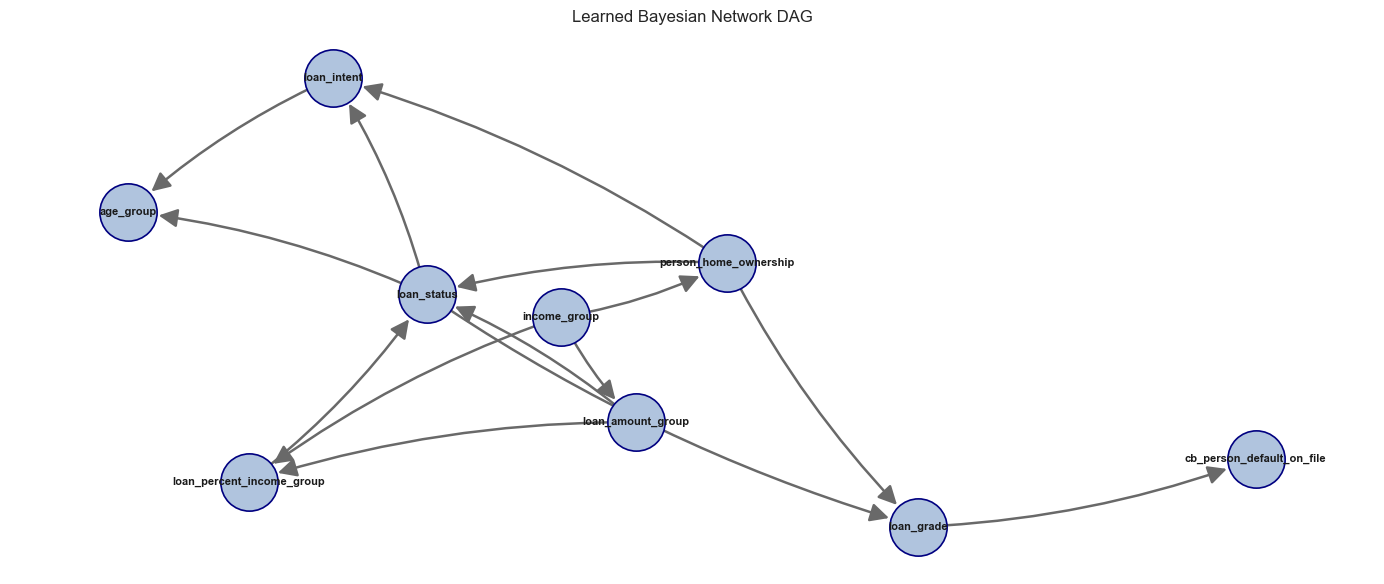

In [267]:
# Plot the learned DAG so dependencies among grouped variables are visible.
dag = nx.DiGraph()
dag.add_nodes_from(bn_cols)
dag.add_edges_from(bn_edges)

plt.figure(figsize=(14, 6))
pos = nx.spring_layout(dag, seed=RANDOM_STATE, k=1.1)
nx.draw_networkx_nodes(
    dag,
    pos,
    node_color="lightsteelblue",
    edgecolors="navy",
    linewidths=1.2,
    node_size=1700,
)
nx.draw_networkx_edges(
    dag,
    pos,
    arrows=True,
    arrowstyle="-|>",
    arrowsize=28,
    edge_color="dimgray",
    width=1.8,
    min_source_margin=18,
    min_target_margin=22,
    connectionstyle="arc3,rad=0.08",
)
nx.draw_networkx_labels(dag, pos, font_size=8, font_weight="bold")
plt.title("Learned Bayesian Network DAG")
plt.axis("off")
plt.tight_layout()
plt.show()

In [268]:
def predict_default_probability_with_bn(model, row, target_col="loan_status"):
    # VariableElimination returns a probability table for loan_status using applicant evidence.
    inference = VariableElimination(model)
    fallback_probability = float((bn_train_data[target_col] == "Default").mean())
    evidence = {
        col: str(row[col])
        for col in bn_cols
        if col != target_col and col in model.nodes()
    }

    try:
        query_result = inference.query(
            variables=[target_col],
            evidence=evidence,
            show_progress=False,
        )
        target_states = list(query_result.state_names[target_col])
        default_index = target_states.index("Default")
        predicted_probability = float(query_result.values[default_index])
        if not np.isfinite(predicted_probability):
            return fallback_probability
        return predicted_probability
    except Exception:
        # If a rare evidence combination is unavailable, fall back to the training default rate.
        return fallback_probability



fallback_probability = float((bn_train_data["loan_status"] == "Default").mean())

# Predict default probability for each Bayesian Network test record.
bn_default_prob = bn_test_data.apply(
    lambda row: predict_default_probability_with_bn(bn_model, row),
    axis=1,
)

bn_default_prob = pd.to_numeric(bn_default_prob, errors="coerce")
bn_default_prob = bn_default_prob.replace([np.inf, -np.inf], np.nan)
fallback_count = int(bn_default_prob.isna().sum())
bn_default_prob = bn_default_prob.fillna(fallback_probability)

bn_true = (bn_test_data["loan_status"] == "Default").astype(int)
bn_pred = (bn_default_prob >= 0.50).astype(int)

print("Bayesian Network fallback probability:", round(fallback_probability, 4))
print("Bayesian Network fallback predictions used:", fallback_count)

# Report the Bayesian Network as a supporting classification model.
bn_metrics = pd.DataFrame([{
    "model_source": "Bayesian Network",
    "model": "pgmpy HillClimbSearch + VariableElimination",
    "roc_auc": roc_auc_score(bn_true, bn_default_prob),
    "accuracy": accuracy_score(bn_true, bn_pred),
    "precision": precision_score(bn_true, bn_pred, zero_division=0),
    "recall": recall_score(bn_true, bn_pred, zero_division=0),
    "f1": f1_score(bn_true, bn_pred, zero_division=0),
}])
display(bn_metrics.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
}))

Bayesian Network fallback probability: 0.2245
Bayesian Network fallback predictions used: 0


,model_source,model,roc_auc,accuracy,precision,recall,f1
0,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,0.8617,0.8649,0.7933,0.5381,0.6412


The Bayesian Network metrics show how well grouped conditional probabilities classify default on the test data. This model is useful for interpretation, while the Scikit-learn classifiers remain the main predictive benchmark.

---
## 4. Classification Modeling

### 4.1 Shared Modeling Preprocessing Pipeline

The same preprocessing step is used before both classification and regression. It fills missing values and changes text columns into numbers. One-hot encoding creates separate 0/1 columns for each category, so models can use columns such as home ownership and loan intent.

In [269]:
# Define target names and feature groups used by the models.
classification_target = "loan_status"
loan_amount_target = "loan_amnt"
loan_percent_target = "loan_percent_income"
interest_rate_target = "loan_int_rate"
interest_rate_target = "loan_int_rate"
interest_rate_target = "loan_int_rate"
interest_rate_target = "loan_int_rate"
interest_rate_target = "loan_int_rate"

numeric_cols = [
    "person_age", "person_income", "person_emp_length", "loan_amnt",
    "loan_percent_income", "loan_int_rate", "cb_person_cred_hist_length",
    "log_person_income", "log_loan_amnt", "income_to_loan_ratio",
    "employment_to_age_ratio", "credit_history_to_age_ratio",
    "default_on_file_binary", "loan_grade_numeric",
]
nominal_cols = [
    "person_home_ownership", "loan_intent", "income_group",
    "loan_amount_group", "loan_percent_income_group", "age_group",
]
binary_cols = ["cb_person_default_on_file"]
ordinal_cols = ["loan_grade"]

classification_feature_cols = numeric_cols + nominal_cols + binary_cols + ordinal_cols
regression_feature_cols = [
    "person_age", "person_income", "person_emp_length",
    "cb_person_cred_hist_length", "log_person_income",
    "employment_to_age_ratio", "credit_history_to_age_ratio",
    "default_on_file_binary", "person_home_ownership", "loan_intent",
    "income_group", "age_group", "cb_person_default_on_file",
]

feature_counts = pd.DataFrame([
    {"feature_set": "classification", "feature_count": len(classification_feature_cols)},
    {"feature_set": "regression", "feature_count": len(regression_feature_cols)},
])
display(feature_counts)

,feature_set,feature_count
0,classification,22
1,regression,13


In [270]:
def make_one_hot_encoder():
    # Use the correct OneHotEncoder argument name for the installed scikit-learn version.
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def make_model_preprocessor(feature_cols):
    # Keep only the columns that are included in the current model feature set.
    model_numeric_cols = [col for col in numeric_cols if col in feature_cols]
    model_nominal_cols = [col for col in nominal_cols if col in feature_cols]
    model_binary_cols = [col for col in binary_cols if col in feature_cols]
    model_ordinal_cols = [col for col in ordinal_cols if col in feature_cols]
    transformers = []

    # Numeric features are median-imputed and standardized for scale-sensitive models.
    if model_numeric_cols:
        transformers.append(("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]), model_numeric_cols))
    # Nominal categorical features are imputed and one-hot encoded.
    if model_nominal_cols:
        transformers.append(("nom", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", make_one_hot_encoder()),
        ]), model_nominal_cols))
    # The default-on-file flag is encoded with a fixed N/Y order.
    if model_binary_cols:
        transformers.append(("bin", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ordinal", OrdinalEncoder(categories=[["N", "Y"]])),
        ]), model_binary_cols))
    # Loan grade is ordinal because grades A through G represent increasing credit risk.
    if model_ordinal_cols:
        transformers.append(("grade", OrdinalEncoder(
            categories=[["A", "B", "C", "D", "E", "F", "G"]],
            handle_unknown="use_encoded_value",
            unknown_value=-1,
        ), model_ordinal_cols))

    # ColumnTransformer combines all preprocessing steps into one reusable object.
    return ColumnTransformer(transformers=transformers, remainder="drop")

The preprocessing object is shared by both classification and regression. The same transformer prepares numeric and categorical columns, and only the final estimator changes depending on whether the task predicts default status or a numeric lending target. This avoids duplicate preprocessing code and keeps model comparisons consistent.

---
### 4.2 ML Classification Models

Scikit-learn models provide a transparent baseline. The result table compares Logistic Regression, Random Forest, Gradient Boosting, and CatBoost if installed.

In [271]:
# Split classification features and target into train and test datasets.
X_cls = df_model[classification_feature_cols].copy()
y_cls = df_model[classification_target].copy()
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(
    X_cls, y_cls, test_size=TEST_SIZE, stratify=y_cls, random_state=RANDOM_STATE
)
split_summary = pd.DataFrame([
    {"dataset": "train", "rows": X_train_cls.shape[0], "features": X_train_cls.shape[1]},
    {"dataset": "test", "rows": X_test_cls.shape[0], "features": X_test_cls.shape[1]},
])
display(split_summary)

,dataset,rows,features
0,train,23653,22
1,test,5914,22


In [272]:
# Define the Scikit-learn classification models for comparison.
classification_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=300, class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
}
try:
    from catboost import CatBoostClassifier
    classification_models["CatBoost"] = CatBoostClassifier(
        iterations=300, learning_rate=0.05, depth=6,
        eval_metric="AUC", random_seed=RANDOM_STATE, verbose=0,
    )
except ImportError:
    print("CatBoost is not installed. Continuing with scikit-learn classifiers.")

In [273]:
def evaluate_classification_models(models, X_train, X_test, y_train, y_test, feature_cols):
    # Store one metric row per model and keep fitted pipelines for later plots.
    rows = []
    fitted_models = {}
    for name, model in models.items():
        # Each model receives the same preprocessing pipeline for a fair comparison.
        pipe = Pipeline([
            ("preprocess", make_model_preprocessor(feature_cols)),
            ("model", clone(model)),
        ])
        # Fit on training data, then evaluate on the holdout test set.
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        y_prob = pipe.predict_proba(X_test)[:, 1]
        # Classification metrics summarize ranking quality and default-class detection.
        rows.append({
            "model": name,
            "roc_auc": roc_auc_score(y_test, y_prob),
            "accuracy": accuracy_score(y_test, y_pred),
            "precision": precision_score(y_test, y_pred, zero_division=0),
            "recall": recall_score(y_test, y_pred, zero_division=0),
            "f1": f1_score(y_test, y_pred, zero_division=0),
        })
        fitted_models[name] = pipe
    # Sort by ROC-AUC because this is the main classification selection metric.
    metrics = pd.DataFrame(rows).sort_values("roc_auc", ascending=False).reset_index(drop=True)
    return metrics, fitted_models


cls_metrics, cls_models = evaluate_classification_models(
    classification_models, X_train_cls, X_test_cls, y_train_cls, y_test_cls, classification_feature_cols
)
sklearn_cls_best = cls_metrics.iloc[[0]].copy()
sklearn_cls_best["model_source"] = "Scikit-learn ML Models"

# Select the best Scikit-learn classifier for threshold tuning and applicant-level inference.
best_cls_name = cls_metrics.iloc[0]["model"]
best_cls_model = cls_models[best_cls_name]
# Generate holdout predictions once so later threshold analysis can reuse them.
y_cls_pred = best_cls_model.predict(X_test_cls)
y_cls_prob = best_cls_model.predict_proba(X_test_cls)[:, 1]

# Display Scikit-learn model results so the strongest baseline is visible.
display(cls_metrics.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
}))

,model,roc_auc,accuracy,precision,recall,f1
0,CatBoost,0.9429,0.9378,0.9908,0.7295,0.8403
1,Random Forest,0.9361,0.9280,0.9144,0.7491,0.8235
2,Gradient Boosting,0.9288,0.9324,0.9576,0.7310,0.8291
3,Logistic Regression,0.8768,0.8074,0.5498,0.7815,0.6455


The classification table compares ML models using ROC-AUC, accuracy, precision, recall, and F1. The highest ROC-AUC model is selected because it best separates default from non-default cases across probability thresholds.

---
### 4.3 Cross-Validation

Cross-validation gives a more stable performance estimate than one train-test split because the model is evaluated across multiple folds.

In [274]:
# Run cross-validation to estimate model performance across multiple folds.
cv_model_name = "CatBoost" if "CatBoost" in classification_models else "Gradient Boosting"
cv_base_model = classification_models[cv_model_name]
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_pipe = Pipeline([
    ("preprocess", make_model_preprocessor(classification_feature_cols)),
    ("model", clone(cv_base_model)),
])
auc_scores = cross_val_score(cv_pipe, X_cls, y_cls, cv=cv, scoring="roc_auc")
oof_pred = cross_val_predict(cv_pipe, X_cls, y_cls, cv=cv)
cv_report = classification_report(y_cls, oof_pred, digits=3, output_dict=True)
cv_results = pd.DataFrame([{
    "model": cv_model_name,
    "cv_auc_mean": auc_scores.mean(),
    "cv_auc_std": auc_scores.std(),
    "default_recall": cv_report["1"]["recall"],
    "default_precision": cv_report["1"]["precision"],
    "default_f1": cv_report["1"]["f1-score"],
}])
display(cv_results.style.format({
    "cv_auc_mean": "{:.4f}", "cv_auc_std": "{:.4f}",
    "default_recall": "{:.4f}", "default_precision": "{:.4f}", "default_f1": "{:.4f}",
}))

,model,cv_auc_mean,cv_auc_std,default_recall,default_precision,default_f1
0,CatBoost,0.9420,0.0012,0.7260,0.9849,0.8359


The cross-validation result checks whether model performance is stable across multiple folds. Similar fold performance gives more confidence than relying only on one train-test split.

---
### 4.4 Threshold Tuning

The default probability threshold of 0.50 may not be the best lending policy. This step chooses a threshold that minimizes a simple business cost where a missed default is more expensive than a false alarm.

In [275]:
# Evaluate thresholds using a simple lending cost assumption.
COST_FALSE_NEGATIVE = 5
COST_FALSE_POSITIVE = 1
threshold_rows = []
for threshold in np.arange(0.05, 0.96, 0.01):
    y_threshold_pred = (y_cls_prob >= threshold).astype(int)
    false_negative = ((y_threshold_pred == 0) & (y_test_cls == 1)).sum()
    false_positive = ((y_threshold_pred == 1) & (y_test_cls == 0)).sum()
    total_cost = COST_FALSE_NEGATIVE * false_negative + COST_FALSE_POSITIVE * false_positive
    threshold_rows.append({
        "threshold": threshold,
        "false_negative": false_negative,
        "false_positive": false_positive,
        "total_cost": total_cost,
    })
threshold_results = pd.DataFrame(threshold_rows)
best_threshold_row = threshold_results.loc[threshold_results["total_cost"].idxmin()]
best_threshold = float(best_threshold_row["threshold"])
display(best_threshold_row.to_frame("value"))

,value
threshold,0.24
false_negative,286.00
false_positive,157.00
total_cost,1587.00


The threshold result identifies a default-probability cutoff based on a simple lending cost assumption. This is important because lending decisions may prefer catching more potential defaults even if that creates more false alarms.

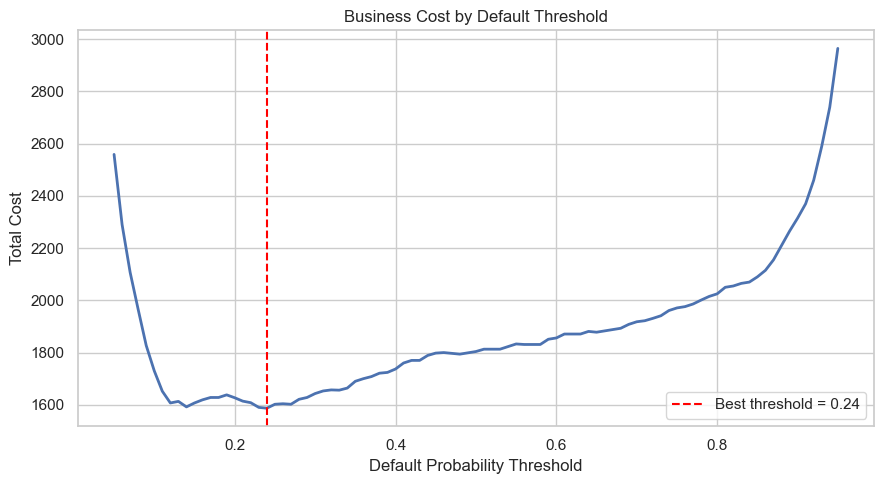

In [276]:
# Plot threshold cost to show the selected operating point.
plt.figure(figsize=(9, 5))
plt.plot(threshold_results["threshold"], threshold_results["total_cost"], linewidth=2)
plt.axvline(best_threshold, color="red", linestyle="--", label=f"Best threshold = {best_threshold:.2f}")
plt.title("Business Cost by Default Threshold")
plt.xlabel("Default Probability Threshold")
plt.ylabel("Total Cost")
plt.legend()
plt.tight_layout()
plt.show()

---
## 5. Regression Modeling

### 5.1 Regression Dataset for Loan Sizing

Regression models are trained only on non-default loans. This creates a more conservative loan sizing benchmark because the models learn from loans that historically performed successfully. The same regression setup also estimates interest rate as an additional numeric lending benchmark.

In [277]:
# Keep only non-default loans for conservative loan-sizing regression.
df_regression = df_model[df_model[classification_target] == 0].copy().reset_index(drop=True)
X_reg = df_regression[regression_feature_cols].copy()
y_loan_amount = df_regression[loan_amount_target].copy()
y_loan_percent = df_regression[loan_percent_target].copy()
y_interest_rate = df_regression[interest_rate_target].copy()
regression_setup_summary = pd.DataFrame([{
    "rows": len(df_regression),
    "features": X_reg.shape[1],
    "loan_amount_mean": y_loan_amount.mean(),
    "loan_percent_mean": y_loan_percent.mean(),
    "interest_rate_mean": y_interest_rate.mean(),
}])
display(regression_setup_summary.style.format({
    "loan_amount_mean": "{:.2f}",
    "loan_percent_mean": "{:.4f}",
    "interest_rate_mean": "{:.2f}",
}))

,rows,features,loan_amount_mean,loan_percent_mean,interest_rate_mean
0,22931,13,8888.32,0.1527,10.47


The regression setup summary confirms that loan-sizing models are trained only on non-default loans. This makes the estimates more conservative because the models learn from loans that historically performed successfully.

In [278]:
# Preview regression predictor columns before model training.
display(X_reg.head())

,person_age,person_income,person_emp_length,cb_person_cred_hist_length,log_person_income,employment_to_age_ratio,credit_history_to_age_ratio,default_on_file_binary,person_home_ownership,loan_intent,income_group,age_group,cb_person_default_on_file
0,21,9600,5.0,2,9.169623,0.238095,0.095238,0,OWN,EDUCATION,Low,Young,N
1,23,115000,2.0,4,11.652696,0.086957,0.173913,0,RENT,EDUCATION,High,Young,N
2,23,120000,0.0,4,11.695255,0.000000,0.173913,0,RENT,EDUCATION,High,Young,N
3,25,137000,9.0,2,11.827744,0.360000,0.080000,1,RENT,PERSONAL,High,Young,Y
4,24,10980,0.0,3,9.303922,0.000000,0.125000,0,OWN,PERSONAL,Low,Young,N


In [279]:
# Split regression data into matching train and test datasets.
X_reg_train, X_reg_test, y_amt_train, y_amt_test = train_test_split(
    X_reg, y_loan_amount, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_pct_train, y_pct_test = train_test_split(
    X_reg, y_loan_percent, test_size=TEST_SIZE, random_state=RANDOM_STATE
)
_, _, y_rate_train, y_rate_test = train_test_split(
    X_reg, y_interest_rate, test_size=TEST_SIZE, random_state=RANDOM_STATE
)

The raw table may still show words such as `RENT` or `DEBTCONSOLIDATION`. This is expected because the pipeline needs the original column names.

The model does not use those text values directly. The preview below shows the encoded regression test data after preprocessing. Category columns become 0/1 columns, while scaled numeric columns can appear as decimal values.

In [280]:
# Fit the shared preprocessor only on regression training features.
regression_preview_preprocessor = make_model_preprocessor(regression_feature_cols)
regression_preview_preprocessor.fit(X_reg_train)

# Transform the regression test features into the numeric matrix used by models.
X_reg_test_encoded = regression_preview_preprocessor.transform(X_reg_test)
if hasattr(X_reg_test_encoded, "toarray"):
    X_reg_test_encoded = X_reg_test_encoded.toarray()

# Use feature names when the installed scikit-learn version supports them.
try:
    regression_encoded_feature_names = regression_preview_preprocessor.get_feature_names_out()
except Exception:
    regression_encoded_feature_names = [f"feature_{i}" for i in range(X_reg_test_encoded.shape[1])]

# Display only a small preview so the table stays readable.
encoded_preview_column_count = min(20, X_reg_test_encoded.shape[1])
X_reg_test_encoded_preview = pd.DataFrame(
    X_reg_test_encoded[:, :encoded_preview_column_count],
    columns=regression_encoded_feature_names[:encoded_preview_column_count],
)
print("Encoded regression test data shape:", X_reg_test_encoded.shape)
display(X_reg_test_encoded_preview.head().round(3))

Encoded regression test data shape: (4587, 27)


,num__person_age,num__person_income,num__person_emp_length,num__cb_person_cred_hist_length,num__log_person_income,num__employment_to_age_ratio,num__credit_history_to_age_ratio,num__default_on_file_binary,nom__person_home_ownership_MORTGAGE,nom__person_home_ownership_OTHER,nom__person_home_ownership_OWN,nom__person_home_ownership_RENT,nom__loan_intent_DEBTCONSOLIDATION,nom__loan_intent_EDUCATION,nom__loan_intent_HOMEIMPROVEMENT,nom__loan_intent_MEDICAL,nom__loan_intent_PERSONAL,nom__loan_intent_VENTURE,nom__income_group_High,nom__income_group_Low
0,0.045,-0.274,-0.205,1.413,-0.065,-0.232,2.065,-0.409,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
1,-0.177,0.372,0.058,-0.994,0.549,0.102,-1.247,-0.409,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
2,1.600,-0.091,-0.732,0.510,0.127,-0.906,0.208,-0.409,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
3,-0.621,0.092,-0.732,-0.994,0.304,-0.721,-1.174,-0.409,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4,0.490,-0.838,-1.258,0.811,-0.789,-1.350,0.998,-0.409,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0


This preview confirms that the regression models receive numbers, not raw text. The one-hot columns are 0/1: 1 means that category is present for that row, and 0 means it is not present. Decimal values are normal for scaled numeric columns such as income, age, and loan amount.

---
### 5.2 ML Regression Models

Regression models predict numeric targets. MAE, RMSE, and R-squared are used to judge how well each model predicts loan amount, loan percentage of income, and interest rate.

In [281]:
# Define Scikit-learn regression models, including linear and tree-based approaches.
regression_models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Random Forest Regressor": RandomForestRegressor(
        n_estimators=300, min_samples_leaf=10,
        random_state=RANDOM_STATE, n_jobs=-1,
    ),
    "Gradient Boosting Regressor": GradientBoostingRegressor(random_state=RANDOM_STATE),
}
try:
    from catboost import CatBoostRegressor
    regression_models["CatBoost Regressor"] = CatBoostRegressor(
        iterations=300, learning_rate=0.05, depth=6,
        loss_function="RMSE", random_seed=RANDOM_STATE, verbose=0,
    )
except ImportError:
    print("CatBoost is not installed. Continuing with scikit-learn regressors.")

In [282]:
def evaluate_regression_models(models, X_train, X_test, y_train, y_test, target_name):
    # Store metric rows and fitted pipelines for each regression target.
    rows = []
    fitted_models = {}
    for name, model in models.items():
        # Use the same preprocessing for every regressor to keep comparison fair.
        pipe = Pipeline([
            ("preprocess", make_model_preprocessor(regression_feature_cols)),
            ("model", clone(model)),
        ])
        # Train the model and predict the holdout test records.
        pipe.fit(X_train, y_train)
        y_pred = pipe.predict(X_test)
        if target_name == loan_percent_target:
            # Loan percent predictions are clipped to a realistic historical range.
            y_pred = np.clip(y_pred, 0, df_regression[loan_percent_target].quantile(0.99))
        # MAE, RMSE, and R-squared describe error size and explanatory strength.
        rows.append({
            "target": target_name,
            "model_source": "Scikit-learn ML Models",
            "model": name,
            "mae": mean_absolute_error(y_test, y_pred),
            "rmse": np.sqrt(mean_squared_error(y_test, y_pred)),
            "r2": r2_score(y_test, y_pred),
        })
        fitted_models[name] = pipe
    # Lower RMSE is used to select the best regression model.
    metrics = pd.DataFrame(rows).sort_values("rmse").reset_index(drop=True)
    return metrics, fitted_models

In [283]:
# Split regression data into matching train and test datasets.
loan_amount_metrics, loan_amount_models = evaluate_regression_models(
    regression_models, X_reg_train, X_reg_test, y_amt_train, y_amt_test, loan_amount_target
)
display(loan_amount_metrics.style.format({"mae": "{:.2f}", "rmse": "{:.2f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_amnt,Scikit-learn ML Models,Gradient Boosting Regressor,3869.13,5047.72,0.1978
1,loan_amnt,Scikit-learn ML Models,CatBoost Regressor,3881.55,5054.02,0.1958
2,loan_amnt,Scikit-learn ML Models,Linear Regression,3882.46,5055.60,0.1953
3,loan_amnt,Scikit-learn ML Models,Ridge Regression,3882.46,5055.62,0.1953
4,loan_amnt,Scikit-learn ML Models,Random Forest Regressor,3897.66,5082.18,0.1868


The loan-amount regression table compares models by prediction error. Lower MAE and RMSE are better, while higher R-squared indicates stronger explanation of loan amount variation.

In [284]:
# Split regression data into matching train and test datasets.
loan_percent_metrics, loan_percent_models = evaluate_regression_models(
    regression_models, X_reg_train, X_reg_test, y_pct_train, y_pct_test, loan_percent_target
)
display(loan_percent_metrics.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_percent_income,Scikit-learn ML Models,Gradient Boosting Regressor,0.0655,0.0820,0.0918
1,loan_percent_income,Scikit-learn ML Models,CatBoost Regressor,0.0656,0.0822,0.0892
2,loan_percent_income,Scikit-learn ML Models,Linear Regression,0.0661,0.0826,0.0798
3,loan_percent_income,Scikit-learn ML Models,Ridge Regression,0.0661,0.0826,0.0798
4,loan_percent_income,Scikit-learn ML Models,Random Forest Regressor,0.0660,0.0827,0.0779


The loan-percent-income regression table evaluates how well models estimate the borrower's loan burden. This target is important because it connects the loan recommendation to applicant income.

In [285]:
# Evaluate models that predict interest rate.
interest_rate_metrics, interest_rate_models = evaluate_regression_models(
    regression_models, X_reg_train, X_reg_test, y_rate_train, y_rate_test, interest_rate_target
)
display(interest_rate_metrics.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_int_rate,Scikit-learn ML Models,CatBoost Regressor,2.0557,2.5305,0.2223
1,loan_int_rate,Scikit-learn ML Models,Gradient Boosting Regressor,2.0547,2.5308,0.2221
2,loan_int_rate,Scikit-learn ML Models,Linear Regression,2.0682,2.5437,0.2141
3,loan_int_rate,Scikit-learn ML Models,Ridge Regression,2.0682,2.5437,0.2141
4,loan_int_rate,Scikit-learn ML Models,Random Forest Regressor,2.0726,2.5554,0.2069


The interest-rate regression table evaluates whether borrower and loan features can estimate the assigned interest rate. This result should be treated as an informational pricing benchmark.

---
### 5.3 Regression Metric Interpretation

**MAE** is the average absolute prediction error. Lower MAE means the model is closer to the actual value on average.

**RMSE** is similar to MAE, but it penalizes large mistakes more strongly. Lower RMSE is better.

**R²** shows how much variation in the target is explained by the model. Higher R² is better, and values closer to 1 indicate stronger predictive performance.

In [286]:
def r2_strength(r2_value):
    # Convert R-squared into a simple project-level interpretation.
    if r2_value >= 0.70:
        return "strong"
    if r2_value >= 0.40:
        return "moderate"
    return "weak"


def regression_conclusion(target_name, best_model, r2_value):
    # Make weak regression performance clear in the conclusion table.
    strength = r2_strength(r2_value)
    if strength == "weak":
        return (
            f"{target_name}: {best_model} has weak prediction performance based on R-squared. "
            "The estimate should be treated as a rough benchmark, not a strong prediction."
        )
    return (
        f"{target_name}: {best_model} has {strength} prediction performance based on R-squared."
    )


best_amount_row = loan_amount_metrics.iloc[0]
best_percent_row = loan_percent_metrics.iloc[0]
best_rate_row = interest_rate_metrics.iloc[0]
best_rate_row = interest_rate_metrics.iloc[0]
best_rate_row = interest_rate_metrics.iloc[0]
best_rate_row = interest_rate_metrics.iloc[0]
best_rate_row = interest_rate_metrics.iloc[0]
amount_mae_ratio = best_amount_row["mae"] / y_amt_test.mean()
amount_rmse_ratio = best_amount_row["rmse"] / y_amt_test.mean()
percent_mae_ratio = best_percent_row["mae"] / y_pct_test.mean()
percent_rmse_ratio = best_percent_row["rmse"] / y_pct_test.mean()
rate_mae_ratio = best_rate_row["mae"] / y_rate_test.mean()
rate_rmse_ratio = best_rate_row["rmse"] / y_rate_test.mean()
rate_mae_ratio = best_rate_row["mae"] / y_rate_test.mean()
rate_rmse_ratio = best_rate_row["rmse"] / y_rate_test.mean()
rate_mae_ratio = best_rate_row["mae"] / y_rate_test.mean()
rate_rmse_ratio = best_rate_row["rmse"] / y_rate_test.mean()
rate_mae_ratio = best_rate_row["mae"] / y_rate_test.mean()
rate_rmse_ratio = best_rate_row["rmse"] / y_rate_test.mean()
rate_mae_ratio = best_rate_row["mae"] / y_rate_test.mean()
rate_rmse_ratio = best_rate_row["rmse"] / y_rate_test.mean()

regression_interpretation = pd.DataFrame([
    {
        "target": loan_amount_target,
        "best_model": best_amount_row["model"],
        "mae": best_amount_row["mae"],
        "rmse": best_amount_row["rmse"],
        "r2": best_amount_row["r2"],
        "mae_vs_target_mean": amount_mae_ratio,
        "rmse_vs_target_mean": amount_rmse_ratio,
        "performance_summary": f"{r2_strength(best_amount_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(loan_amount_target, best_amount_row["model"], best_amount_row["r2"]),
    },
    {
        "target": loan_percent_target,
        "best_model": best_percent_row["model"],
        "mae": best_percent_row["mae"],
        "rmse": best_percent_row["rmse"],
        "r2": best_percent_row["r2"],
        "mae_vs_target_mean": percent_mae_ratio,
        "rmse_vs_target_mean": percent_rmse_ratio,
        "performance_summary": f"{r2_strength(best_percent_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(loan_percent_target, best_percent_row["model"], best_percent_row["r2"]),
    },
    {
        "target": interest_rate_target,
        "best_model": best_rate_row["model"],
        "mae": best_rate_row["mae"],
        "rmse": best_rate_row["rmse"],
        "r2": best_rate_row["r2"],
        "mae_vs_target_mean": rate_mae_ratio,
        "rmse_vs_target_mean": rate_rmse_ratio,
        "performance_summary": f"{r2_strength(best_rate_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(interest_rate_target, best_rate_row["model"], best_rate_row["r2"]),
    },
    {
        "target": interest_rate_target,
        "best_model": best_rate_row["model"],
        "mae": best_rate_row["mae"],
        "rmse": best_rate_row["rmse"],
        "r2": best_rate_row["r2"],
        "mae_vs_target_mean": rate_mae_ratio,
        "rmse_vs_target_mean": rate_rmse_ratio,
        "performance_summary": f"{r2_strength(best_rate_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(interest_rate_target, best_rate_row["model"], best_rate_row["r2"]),
    },
    {
        "target": interest_rate_target,
        "best_model": best_rate_row["model"],
        "mae": best_rate_row["mae"],
        "rmse": best_rate_row["rmse"],
        "r2": best_rate_row["r2"],
        "mae_vs_target_mean": rate_mae_ratio,
        "rmse_vs_target_mean": rate_rmse_ratio,
        "performance_summary": f"{r2_strength(best_rate_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(interest_rate_target, best_rate_row["model"], best_rate_row["r2"]),
    },
    {
        "target": interest_rate_target,
        "best_model": best_rate_row["model"],
        "mae": best_rate_row["mae"],
        "rmse": best_rate_row["rmse"],
        "r2": best_rate_row["r2"],
        "mae_vs_target_mean": rate_mae_ratio,
        "rmse_vs_target_mean": rate_rmse_ratio,
        "performance_summary": f"{r2_strength(best_rate_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(interest_rate_target, best_rate_row["model"], best_rate_row["r2"]),
    },
    {
        "target": interest_rate_target,
        "best_model": best_rate_row["model"],
        "mae": best_rate_row["mae"],
        "rmse": best_rate_row["rmse"],
        "r2": best_rate_row["r2"],
        "mae_vs_target_mean": rate_mae_ratio,
        "rmse_vs_target_mean": rate_rmse_ratio,
        "performance_summary": f"{r2_strength(best_rate_row['r2']).title()} explanatory performance by R-squared.",
        "conclusion": regression_conclusion(interest_rate_target, best_rate_row["model"], best_rate_row["r2"]),
    },
])

# Display the metric interpretation and final regression conclusion for each target.
display(regression_interpretation.style.format({
    "mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}",
    "mae_vs_target_mean": "{:.2%}", "rmse_vs_target_mean": "{:.2%}",
}))

,target,best_model,mae,rmse,r2,mae_vs_target_mean,rmse_vs_target_mean,performance_summary,conclusion
0,loan_amnt,Gradient Boosting Regressor,3869.1325,5047.7249,0.1978,43.84%,57.20%,Weak explanatory performance by R-squared.,"loan_amnt: Gradient Boosting Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
1,loan_percent_income,Gradient Boosting Regressor,0.0655,0.0820,0.0918,43.03%,53.93%,Weak explanatory performance by R-squared.,"loan_percent_income: Gradient Boosting Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
2,loan_int_rate,CatBoost Regressor,2.0557,2.5305,0.2223,19.73%,24.29%,Weak explanatory performance by R-squared.,"loan_int_rate: CatBoost Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
3,loan_int_rate,CatBoost Regressor,2.0557,2.5305,0.2223,19.73%,24.29%,Weak explanatory performance by R-squared.,"loan_int_rate: CatBoost Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
4,loan_int_rate,CatBoost Regressor,2.0557,2.5305,0.2223,19.73%,24.29%,Weak explanatory performance by R-squared.,"loan_int_rate: CatBoost Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
5,loan_int_rate,CatBoost Regressor,2.0557,2.5305,0.2223,19.73%,24.29%,Weak explanatory performance by R-squared.,"loan_int_rate: CatBoost Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."
6,loan_int_rate,CatBoost Regressor,2.0557,2.5305,0.2223,19.73%,24.29%,Weak explanatory performance by R-squared.,"loan_int_rate: CatBoost Regressor has weak prediction performance based on R-squared. The estimate should be treated as a rough benchmark, not a strong prediction."


The best regression models are selected here for the later applicant-level loan estimate. This keeps model selection separate from plots and makes the inference example easier to follow.

In [287]:
# Select the best regression models by the sorted metric tables.
best_amount_name = loan_amount_metrics.iloc[0]["model"]
best_percent_name = loan_percent_metrics.iloc[0]["model"]
best_rate_name = interest_rate_metrics.iloc[0]["model"]
best_rate_name = interest_rate_metrics.iloc[0]["model"]
best_rate_name = interest_rate_metrics.iloc[0]["model"]
best_rate_name = interest_rate_metrics.iloc[0]["model"]

# Store the fitted pipelines so they can be reused for one-applicant inference.
best_amount_model = loan_amount_models[best_amount_name]
best_percent_model = loan_percent_models[best_percent_name]
best_rate_model = interest_rate_models[best_rate_name]
best_rate_model = interest_rate_models[best_rate_name]
best_rate_model = interest_rate_models[best_rate_name]
best_rate_model = interest_rate_models[best_rate_name]

# Display the selected models before the final comparison and example sections.
selected_regression_models = pd.DataFrame([
    {"target": loan_amount_target, "selected_model": best_amount_name},
    {"target": loan_percent_target, "selected_model": best_percent_name},
    {"target": interest_rate_target, "selected_model": best_rate_name},
])
display(selected_regression_models)

,target,selected_model
0,loan_amnt,Gradient Boosting Regressor
1,loan_percent_income,Gradient Boosting Regressor
2,loan_int_rate,CatBoost Regressor


In [288]:
# Select the best regression models by the sorted metric tables.
best_amount_name = loan_amount_metrics.iloc[0]["model"]
best_percent_name = loan_percent_metrics.iloc[0]["model"]
best_rate_name = interest_rate_metrics.iloc[0]["model"]
best_rate_name = interest_rate_metrics.iloc[0]["model"]
best_rate_name = interest_rate_metrics.iloc[0]["model"]

# Store the fitted pipelines so they can be reused for one-applicant inference.
best_amount_model = loan_amount_models[best_amount_name]
best_percent_model = loan_percent_models[best_percent_name]
best_rate_model = interest_rate_models[best_rate_name]
best_rate_model = interest_rate_models[best_rate_name]
best_rate_model = interest_rate_models[best_rate_name]

# Display the selected models before the final comparison and example sections.
selected_regression_models = pd.DataFrame([
    {"target": loan_amount_target, "selected_model": best_amount_name},
    {"target": loan_percent_target, "selected_model": best_percent_name},
    {"target": interest_rate_target, "selected_model": best_rate_name},
])
display(selected_regression_models)

,target,selected_model
0,loan_amnt,Gradient Boosting Regressor
1,loan_percent_income,Gradient Boosting Regressor
2,loan_int_rate,CatBoost Regressor


---
## 6. Model Comparison and Applicant Inference

### 6.1 Model Comparison

The tables below compare the final Scikit-learn classification, Bayesian Network classification, and Scikit-learn regression results used in this project.

### 6.1.1 Classification Model Comparison

In [289]:
classification_compare_parts = [sklearn_cls_best[["model_source", "model", "roc_auc", "accuracy", "precision", "recall", "f1"]]]
if bn_metrics is not None:
    classification_compare_parts.append(bn_metrics[["model_source", "model", "roc_auc", "accuracy", "precision", "recall", "f1"]])
classification_comparison = pd.concat(classification_compare_parts, ignore_index=True)

# Display Scikit-learn and Bayesian Network classification results together.
display(classification_comparison.style.format({
    "roc_auc": "{:.4f}", "accuracy": "{:.4f}", "precision": "{:.4f}",
    "recall": "{:.4f}", "f1": "{:.4f}",
}))

,model_source,model,roc_auc,accuracy,precision,recall,f1
0,Scikit-learn ML Models,CatBoost,0.9429,0.9378,0.9908,0.7295,0.8403
1,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,0.8617,0.8649,0.7933,0.5381,0.6412


### 6.1.2 Regression Model Comparison: Loan Amount

In [290]:
amount_model_comparison = loan_amount_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]].copy()

# Display the best Scikit-learn model for loan amount.
display(amount_model_comparison.style.format({"mae": "{:.2f}", "rmse": "{:.2f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_amnt,Scikit-learn ML Models,Gradient Boosting Regressor,3869.13,5047.72,0.1978


### 6.1.3 Regression Model Comparison: Loan Percent Income

In [291]:
percent_model_comparison = loan_percent_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]].copy()

# Display the best Scikit-learn model for loan percent income.
display(percent_model_comparison.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_percent_income,Scikit-learn ML Models,Gradient Boosting Regressor,0.0655,0.0820,0.0918


### 6.1.4 Regression Model Comparison: Interest Rate

In [292]:
interest_rate_model_comparison = interest_rate_metrics.iloc[[0]][["target", "model_source", "model", "mae", "rmse", "r2"]].copy()

# Display the best Scikit-learn model for interest rate.
display(interest_rate_model_comparison.style.format({"mae": "{:.4f}", "rmse": "{:.4f}", "r2": "{:.4f}"}))

,target,model_source,model,mae,rmse,r2
0,loan_int_rate,Scikit-learn ML Models,CatBoost Regressor,2.0557,2.5305,0.2223


---
### 6.2 Example Applicant Default Prediction

This example applies the classification models to one applicant record. The Scikit-learn machine learning model uses the same engineered features as training, while the Bayesian Network uses grouped categorical evidence because its probability tables are learned from discrete variables.

The output shows the estimated probability of default, the class predicted at a 0.50 threshold, and a readable label for both approaches.

In [293]:
example_applicant = {
    "person_age": 28,
    "person_income": 65000,
    "person_home_ownership": "RENT",
    "person_emp_length": 5,
    "loan_intent": "DEBTCONSOLIDATION",
    "loan_grade": "G",
    "loan_amnt": 12000,
    "loan_int_rate": 11.0,
    "loan_percent_income": 12000 / 65000,
    "loan_status": 0,
    "cb_person_default_on_file": "N",
    "cb_person_cred_hist_length": 6,
}


def prepare_applicant_for_classification(applicant_dict):
    # Convert one applicant dictionary into a dataframe.
    applicant_df = pd.DataFrame([applicant_dict])
    # Apply the same feature engineering used before model training.
    applicant_df = add_credit_features(applicant_df)
    # Keep only the predictor columns expected by the classification pipeline.
    return applicant_df[classification_feature_cols]


def prepare_applicant_for_bayesian_network(applicant_dict):
    # Convert the applicant into the grouped/discrete format used by the Bayesian Network.
    applicant_df = pd.DataFrame([applicant_dict])
    applicant_df = add_credit_features(applicant_df)
    bn_applicant = applicant_df[bn_cols].copy()
    # Match the target labels used when the Bayesian Network was trained.
    bn_applicant["loan_status"] = bn_applicant["loan_status"].map({0: "Non-Default", 1: "Default"})
    return bn_applicant.astype(str).iloc[0]


def default_label(probability, threshold=0.50):
    # Convert a probability into the same decision label used in the classification task.
    return "Default" if probability >= threshold else "Non-Default"

In [294]:
# Prepare the applicant for the best Scikit-learn machine learning classifier.
applicant_cls_features = prepare_applicant_for_classification(example_applicant)

# Predict default probability and convert it into a class at the 0.50 threshold.
sklearn_default_probability = float(best_cls_model.predict_proba(applicant_cls_features)[:, 1][0])
sklearn_predicted_class = int(sklearn_default_probability >= 0.50)

# Prepare grouped evidence for Bayesian Network inference.
bn_applicant_row = prepare_applicant_for_bayesian_network(example_applicant)
bayesian_default_probability = predict_default_probability_with_bn(bn_model, bn_applicant_row)
bayesian_predicted_class = int(bayesian_default_probability >= 0.50)

# Present both applicant-level default predictions in one compact table.
applicant_default_prediction = pd.DataFrame([
    {
        "model_source": "Scikit-learn ML",
        "model": best_cls_name,
        "default_probability": sklearn_default_probability,
        "predicted_class": sklearn_predicted_class,
        "predicted_label": default_label(sklearn_default_probability),
    },
    {
        "model_source": "Bayesian Network",
        "model": "pgmpy HillClimbSearch + VariableElimination",
        "default_probability": bayesian_default_probability,
        "predicted_class": bayesian_predicted_class,
        "predicted_label": default_label(bayesian_default_probability),
    },
])
display(applicant_default_prediction.style.format({"default_probability": "{:.2%}"}))

,model_source,model,default_probability,predicted_class,predicted_label
0,Scikit-learn ML,CatBoost,99.70%,1,Default
1,Bayesian Network,pgmpy HillClimbSearch + VariableElimination,85.36%,1,Default


The applicant default-prediction table gives two probability-based views for the same applicant. A predicted label of Default means the estimated probability is at least 0.50; Non-Default means it is below 0.50.

---
### 6.3 Example Applicant Loan Estimate

The example shows how the regression models can estimate a loan amount and loan percentage for one applicant. The conservative recommendation is the lower of the direct loan amount estimate and the income-based estimate.

In [295]:
def prepare_applicant_for_regression(applicant_dict):
    # Convert one applicant dictionary into a dataframe.
    applicant_df = pd.DataFrame([applicant_dict])
    # Apply the same feature engineering used during model training.
    applicant_df = add_credit_features(applicant_df)
    # Keep only the regression predictor columns expected by the trained pipelines.
    return applicant_df[regression_feature_cols]


def estimate_loan_for_applicant(applicant_dict, amount_model, percent_model, rate_model):
    # Prepare the applicant record in the same format as the regression training data.
    applicant_features = prepare_applicant_for_regression(applicant_dict)
    # Predict loan amount directly from the loan amount regression model.
    predicted_amount = float(amount_model.predict(applicant_features)[0])
    
    # Predict loan percent of income from the loan burden regression model.
    predicted_percent = float(percent_model.predict(applicant_features)[0])
    
    max_reasonable_percent = float(df_regression[loan_percent_target].quantile(0.99))
    # Clip extreme percentage predictions to the historical non-default range.
    predicted_percent = float(np.clip(predicted_percent, 0, max_reasonable_percent))
    
    # Predict interest rate as an informational estimate.
    predicted_interest_rate = float(rate_model.predict(applicant_features)[0])
    
    # Convert the predicted percentage into an income-based dollar amount.
    income_based_amount = float(applicant_dict["person_income"]) * predicted_percent
    # Use the smaller amount as the conservative recommendation.
    conservative_amount = min(predicted_amount, income_based_amount)
    return {
        "predicted_loan_amount": round(predicted_amount, 2),
        "predicted_loan_percent_income": round(predicted_percent, 4),
        "predicted_interest_rate": round(predicted_interest_rate, 4),
        "income_based_amount": round(income_based_amount, 2),
        "conservative_recommended_amount": round(conservative_amount, 2),
    }

In [296]:
# Reuse the same example applicant from the default-prediction section.
loan_estimate = estimate_loan_for_applicant(example_applicant, best_amount_model, best_percent_model, best_rate_model)
loan_estimate_table = pd.DataFrame([loan_estimate])

# Display the final applicant estimate table.
display(loan_estimate_table)

# Print the rule used to calculate the conservative recommendation.
print("Interpretation: the conservative recommendation is the lower of the direct loan amount estimate and the income-based estimate.")

,predicted_loan_amount,predicted_loan_percent_income,predicted_interest_rate,income_based_amount,conservative_recommended_amount
0,8943.68,0.1377,10.0603,8952.72,8943.68


Interpretation: the conservative recommendation is the lower of the direct loan amount estimate and the income-based estimate.


The loan-estimate table combines direct loan amount prediction with an income-based estimate. The conservative recommendation uses the lower of those two values so the final amount is not higher than the model's affordability estimate.